# Foreign-object detection in lentils with Dinomaly and Cuvis.AI

This tutorial runs **trained Dinomaly anomaly-detection pipelines** on a hyperspectral
CU3S video of lentils moving under a conveyor belt. The goal is to find foreign objects
such as stones, stems, aluminum shards, and flies in otherwise normal lentils.

We compare three ways of converting the hyperspectral cube into the 3-channel input that
Dinomaly expects:

1. **RGB**: visible-light false/true color style input.
2. **CIR**: color-infrared input using near-infrared information.
3. **Custom selector**: three fixed bands that performed well for the frozen AdaCLIP selector.

**Example channel views.** These are static PNGs made by selecting the
method’s three bands, applying per-channel min-max normalization, and scaling to `uint8 [0,255]`.

| RGB view | CIR view | Custom selector view |
|---|---|---|
| ![rgb](outputs/Auto_003+01/channel_examples/rgb_minmax_u8_frame27.png) | ![cir](outputs/Auto_003+01/channel_examples/cir_minmax_u8_frame27.png) | ![custom](outputs/Auto_003+01/channel_examples/custom_minmax_u8_frame27.png) |

The tutorial follows this flow:

```
CU3S session + JSON GT
    -> RGB / CIR / Custom 3-channel view
    -> trained Dinomaly detector
    -> anomaly heatmap
    -> image gate + pixel quantile threshold
    -> final mask and overlay video
```

> **Prerequisites**
>
> 1. Run from `/home/dev/anish/cuvis-ai-dinomaly`.
> 2. Start Jupyter with the repo environment: `source .venv/bin/activate && jupyter lab`.
> 3. The local CU3S video, JSON annotations, and trained YAML/PT files must exist at the paths configured below.
> 4. `graphviz dot` is optional but recommended for pipeline graph rendering.
> 5. Video export uses `ToVideoNode` first and falls back to an OpenCV writer if needed.

In [1]:
# Colab bootstrap — this tutorial is primarily local because it uses local CU3S/model paths.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("This tutorial expects local CU3S/model files. Mount or download those files before continuing.")

In [2]:
%matplotlib inline
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, Video, display
from loguru import logger

# Robust import whether Jupyter's cwd is repo root or this notebook folder.
REPO_ROOT = Path('/home/dev/anish/cuvis-ai-dinomaly')
NOTEBOOK_DIR = REPO_ROOT / 'notebooks' / 'lentils_sliding'
for p in (REPO_ROOT, NOTEBOOK_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from utils import (
    METHOD_TITLES,
    assert_paths_exist,
    export_overlay_video,
    iou,
    load_pipeline_for_inference,
    load_reference_metrics,
    make_predict_loader,
    render_input_triplet,
    render_method_triplet,
    resolve_default_config,
    run_method_on_frame_subset,
    summarize_subset,
)

pd.set_option('display.max_colwidth', 120)

device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
    device = torch.device('mps')
logger.info(f'Using device {device}')

2026-05-04 14:14:02.467 | INFO     | __main__:<module>:43 - Using device cuda


## 1 · Dataset and objective

The lentils video is a CU3S session: each frame stores a hyperspectral cube
`H x W x C`, not just RGB pixels. The matching JSON contains object masks.

In this use case, class `0` is normal/background. Any non-zero label is treated as
foreign material for anomaly-detection evaluation.

Typical classes in this sequence:

- stone
- stem_k
- alu_shard
- fly

The detector never sees these labels during inference. It only outputs anomaly scores;
we use GT masks afterwards to explain and evaluate predictions.

In [3]:
config = resolve_default_config()
assert_paths_exist(config)

cu3s_file_path = config['cu3s_path']
annotation_json_path = config['annotation_json_path']
comparison_json_path = config['method_comparison_json']
output_dir = NOTEBOOK_DIR / 'outputs' / 'Auto_003+01'
output_dir.mkdir(parents=True, exist_ok=True)

print(f'CU3S: {cu3s_file_path}')
print(f'Annotations: {annotation_json_path}')
print(f'Method comparison JSON: {comparison_json_path}')
print(f'Output directory: {output_dir}')

CU3S: /mnt/data/lentils_videos/sliding/Auto_003+01.cu3s
Annotations: /mnt/data/lentils_videos/sliding/Auto_003+01.json
Method comparison JSON: /mnt/data/cuvis_ai_outputs/lentils_video_suite_npz/dinomaly/sliding/Auto_003+01/method_comparison.json
Output directory: /home/dev/anish/cuvis-ai-dinomaly/notebooks/lentils_sliding/outputs/Auto_003+01


## 2 · Why compare RGB, CIR, and Custom selector?

Dinomaly consumes a 3-channel image, but the camera measures many spectral bands.
The key question is therefore: **which three channels should represent the cube?**

- **RGB** is intuitive and presentation-friendly, but many foreign materials are not strongly separated in visible color.
- **CIR** injects near-infrared information, which can reveal material differences invisible to RGB.
- **Custom selector** uses fixed bands `[14, 59, 57]` from the selector experiment. It is less visually familiar, but often better aligned with the anomaly task.

The same Dinomaly architecture is used; only the 3-channel view changes.

In [4]:
ref_metrics = load_reference_metrics(comparison_json_path)
metrics_df = pd.DataFrame(ref_metrics).T.rename_axis('method').reset_index()
metrics_df['display_name'] = metrics_df['method'].map(METHOD_TITLES)
metrics_df[['display_name', 'pixel_auroc', 'image_auroc', 'pixel_iou', 'image_f1']]

,display_name,pixel_auroc,image_auroc,pixel_iou,image_f1
0,Dinomaly CIR,0.991810,1.000000,0.282097,0.926316
1,Dinomaly Custom Selector,0.993851,1.000000,0.311961,0.990291
2,Dinomaly RGB,0.905450,0.820261,0.164528,0.869565


## 3 · Build/load the Dinomaly pipelines

The trained pipelines are loaded from YAML/PT pairs. For transparency we render one
pipeline graph just like the blood-perfusion tutorial does.

The loaded graph is conceptually:

```
CU3SDataNode -> channel selector -> DinomalyDetector -> TwoStageBinaryDecider
```



2026-05-04 14:14:02.509 | INFO     | cuvis_ai_core.utils.node_registry:_ensure_local_plugin:547 - Using local plugin 'dinomaly' at /home/dev/anish/cuvis-ai-dinomaly


2026-05-04 14:14:02.511 | DEBUG    | cuvis_ai_core.utils.git_and_os:_extract_deps_from_pyproject:265 - Extracted 9 dependencies from /home/dev/anish/cuvis-ai-dinomaly/pyproject.toml


2026-05-04 14:14:02.511 | INFO     | cuvis_ai_core.utils.git_and_os:_install_plugin_dependencies:246 - Installing 9 dependencies for plugin 'dinomaly'...


2026-05-04 14:14:02.511 | INFO     | cuvis_ai_core.utils.git_and_os:_install_dependencies_with_uv:273 - Dependencies to install: cuvis-ai>=0.1.0, cuvis-ai-core>=0.1.0, anomalib==2.1.0, kornia==0.6.12, numpy>=1.20.0, opencv-python>=4.8.0, tqdm>=4.66.0, defusedxml>=0.7.1, open-clip-torch>=2.24.0


2026-05-04 14:14:02.530 | INFO     | cuvis_ai_core.utils.git_and_os:_install_dependencies_with_uv:285 - ✓ Plugin 'dinomaly' dependencies installed successfully


...


DINOv2 dinov2_reg base weights:  98%|█████████▊| 338M/346M [00:06<00:00, 49.4MB/s]


DINOv2 dinov2_reg base weights:  99%|█████████▉| 343M/346M [00:07<00:00, 49.4MB/s]


DINOv2 dinov2_reg base weights: 346MB [00:07, 48.9MB/s]                           

/home/dev/anish/cuvis-ai/.venv/lib/python3.11/site-packages/cuvis_ai_core/pipeline/factory.py:232: MissingNodeMetadataWarning: Node class cuvis_ai_dinomaly.node.dinomaly_detector.DinomalyDetector is missing explicit _category and _tags. Declare on the class body, e.g.:
    _category = NodeCategory.TRANSFORM  # graph role: SOURCE / SINK / TRANSFORM / MODEL / LOSS / METRIC / REGULARIZER / OPTIMIZER / SCHEDULER / RUNNER / CONTROL / VISUALIZER
    _tags = frozenset({NodeTag.HYPERSPECTRAL, NodeTag.PREPROCESSING})  # any modality / task / lifecycle / property / backend tags that apply
  pipeline._assign_counter_and_add_node(node)


2026-05-04 14:14:12.244 | SUCCESS  | cuvis_ai_core.pipeline.visualizer:render_graphviz:288 - Graphviz visualization saved to /home/dev/anish/cuvis-ai-dinomaly/notebooks/lentils_sliding/outputs/Auto_003+01/dinomaly_concrete_pipeline_graph.png


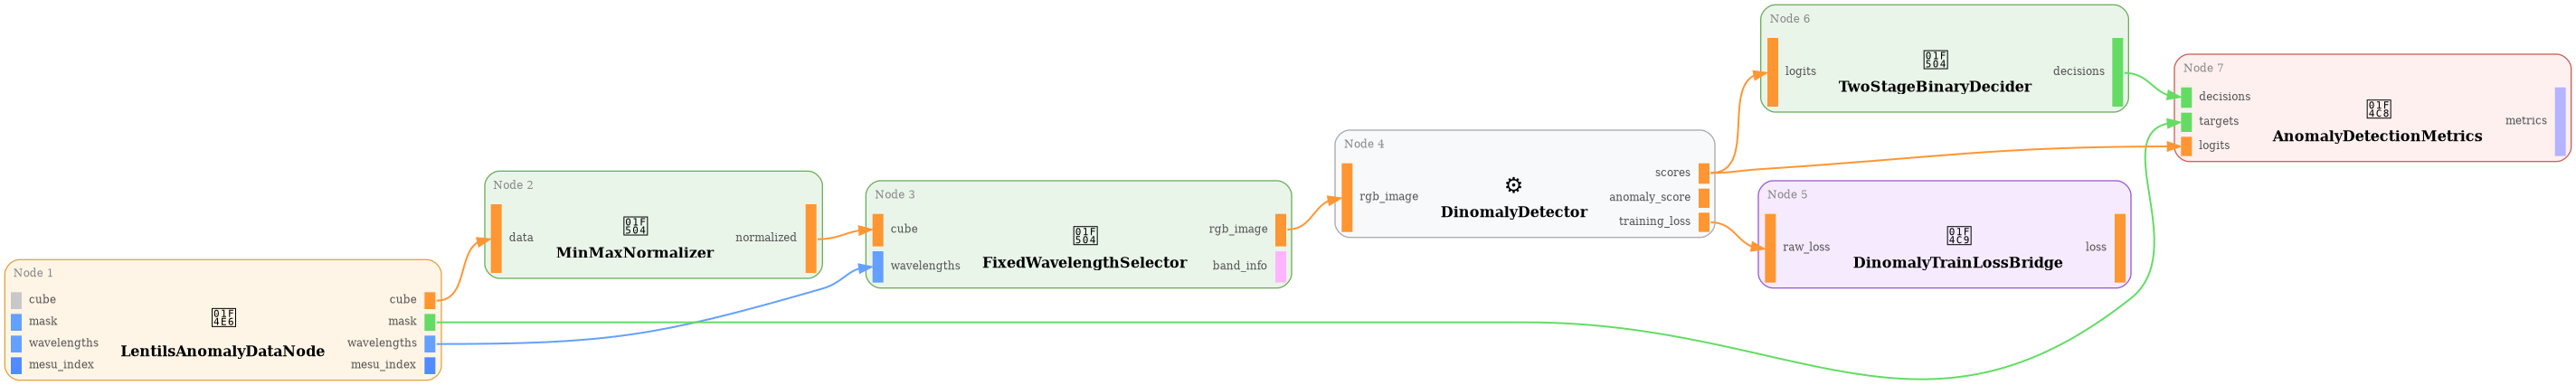

In [5]:
# Load one pipeline and render its graph for explanation.
graph_method = config['methods'][2]  # Custom selector, usually the most interesting one.
graph_pipeline = load_pipeline_for_inference(
    yaml_path=graph_method.yaml_path,
    pt_path=graph_method.pt_path,
    plugins_manifest=config['plugins_manifest'],
    device=str(device),
)

graph_png = graph_pipeline.visualize(
    format='render_graphviz',
    output_path=str(output_dir / f'{graph_method.name}_pipeline_graph.png'),
)
display(Image(str(graph_png)))

## 4 · Sanity-check on a frame with objects

Before running all frames, inspect a frame that actually contains annotations.
Frame `27` in this sequence has multiple object masks, so it is a useful visual example.

This step runs live inference on a few selected frames, not cached NPZ outputs.

In [6]:
PREVIEW_FRAME_ID = 27
FRAME_INDICES = [18, 24, PREVIEW_FRAME_ID, 30]
NORMAL_CLASS_IDS = {0}

dm, loader = make_predict_loader(
    cu3s_file_path,
    annotation_json_path,
    processing_mode='Reflectance',
    batch_size=1,
)
print(f'Total CU3S measurements: {len(dm.predict_ds)}')
print(f'Preview frame: {PREVIEW_FRAME_ID}')
print(f'Frames for quick comparison: {FRAME_INDICES}')

2026-05-04 14:14:24.715 | INFO     | cuvis_ai_core.data.datasets:__init__:95 - Loaded cu3s dataset from /mnt/data/lentils_videos/sliding/Auto_003+01.cu3s with 69 measurements: [0..68]


2026-05-04 14:14:24.720 | INFO     | cuvis_ai_core.data.datasets:__init__:118 - Category map: {0: 'Unlabeled', 1: 'stone', 2: 'stem_k', 3: 'alu_shard', 4: 'fly'}


Total CU3S measurements: 69
Preview frame: 27
Frames for quick comparison: [18, 24, 27, 30]


In [7]:
preview_results = {}

for method in config['methods']:
    print(f'Running preview inference for {method.title} ...')
    pipe = load_pipeline_for_inference(
        yaml_path=method.yaml_path,
        pt_path=method.pt_path,
        plugins_manifest=config['plugins_manifest'],
        device=str(device),
    )
    rows = run_method_on_frame_subset(
        pipeline=pipe,
        loader=loader,
        frame_indices=set(FRAME_INDICES),
        image_threshold=method.image_threshold,
        quantile=method.quantile,
        top_k_fraction=method.top_k_fraction,
        device=device,
        normal_class_ids=NORMAL_CLASS_IDS,
    )
    preview_results[method.name] = rows

counts = {k: len(v) for k, v in preview_results.items()}
print(counts)
assert all(v > 0 for v in counts.values()), 'No preview rows were produced for at least one method.' 

2026-05-04 14:14:24.739 | INFO     | cuvis_ai_core.utils.node_registry:_ensure_local_plugin:547 - Using local plugin 'dinomaly' at /home/dev/anish/cuvis-ai-dinomaly


2026-05-04 14:14:24.741 | DEBUG    | cuvis_ai_core.utils.git_and_os:_extract_deps_from_pyproject:265 - Extracted 9 dependencies from /home/dev/anish/cuvis-ai-dinomaly/pyproject.toml


2026-05-04 14:14:24.741 | INFO     | cuvis_ai_core.utils.git_and_os:_install_plugin_dependencies:246 - Installing 9 dependencies for plugin 'dinomaly'...


2026-05-04 14:14:24.741 | INFO     | cuvis_ai_core.utils.git_and_os:_install_dependencies_with_uv:273 - Dependencies to install: cuvis-ai>=0.1.0, cuvis-ai-core>=0.1.0, anomalib==2.1.0, kornia==0.6.12, numpy>=1.20.0, opencv-python>=4.8.0, tqdm>=4.66.0, defusedxml>=0.7.1, open-clip-torch>=2.24.0


2026-05-04 14:14:24.762 | INFO     | cuvis_ai_core.utils.git_and_os:_install_dependencies_with_uv:285 - ✓ Plugin 'dinomaly' dependencies installed successfully


...

2026-05-04 14:15:43.248 | DEBUG    | cuvis_ai.node.deciders.two_stage_decider:forward:156 - TwoStageDecider: image_score=0.213084 >= threshold=0.151000, applying quantile thresholding (q=0.995)


2026-05-04 14:15:44.675 | DEBUG    | cuvis_ai.node.deciders.two_stage_decider:forward:111 - TwoStageDecider input: shape=torch.Size([1, 1000, 1080, 1]), device=cuda:0, dtype=torch.float32, min=0.046255, max=0.237356, mean=0.080070


2026-05-04 14:15:44.677 | DEBUG    | cuvis_ai.node.deciders.two_stage_decider:forward:138 - TwoStageDecider[batch=0]: k=1080, topk_min=0.199136, topk_max=0.237356, image_score=0.216080


2026-05-04 14:15:44.677 | DEBUG    | cuvis_ai.node.deciders.two_stage_decider:forward:156 - TwoStageDecider: image_score=0.216080 >= threshold=0.151000, applying quantile thresholding (q=0.995)


{'dinomaly_rgb': 4, 'dinomaly_cir': 4, 'dinomaly_concrete': 4}


## 5 · What goes into the detectors?

The next figure shows the **same physical frame** rendered as the three model inputs.
This is useful for explaining why RGB may miss subtle material differences while CIR or custom bands can make them more separable.

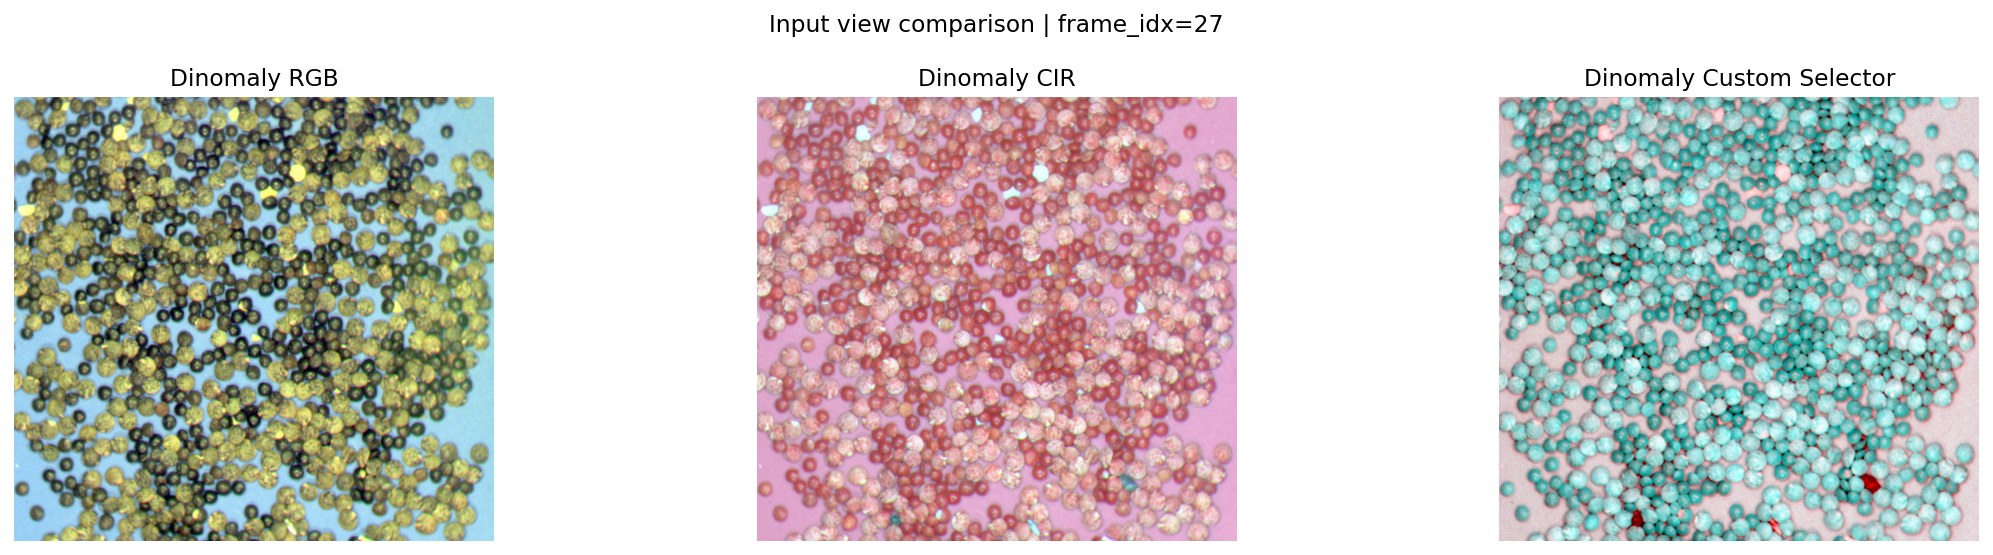

In [8]:
render_input_triplet(preview_results, frame_idx=PREVIEW_FRAME_ID)
plt.show()

## 6 · Predictions, heatmaps, and overlays

Each method produces:

- a 3-channel input view,
- a dense anomaly heatmap,
- a thresholded predicted mask,
- a GT/prediction overlay.

Overlay colors:

- green: GT object pixels
- red: predicted object pixels
- yellow: overlap

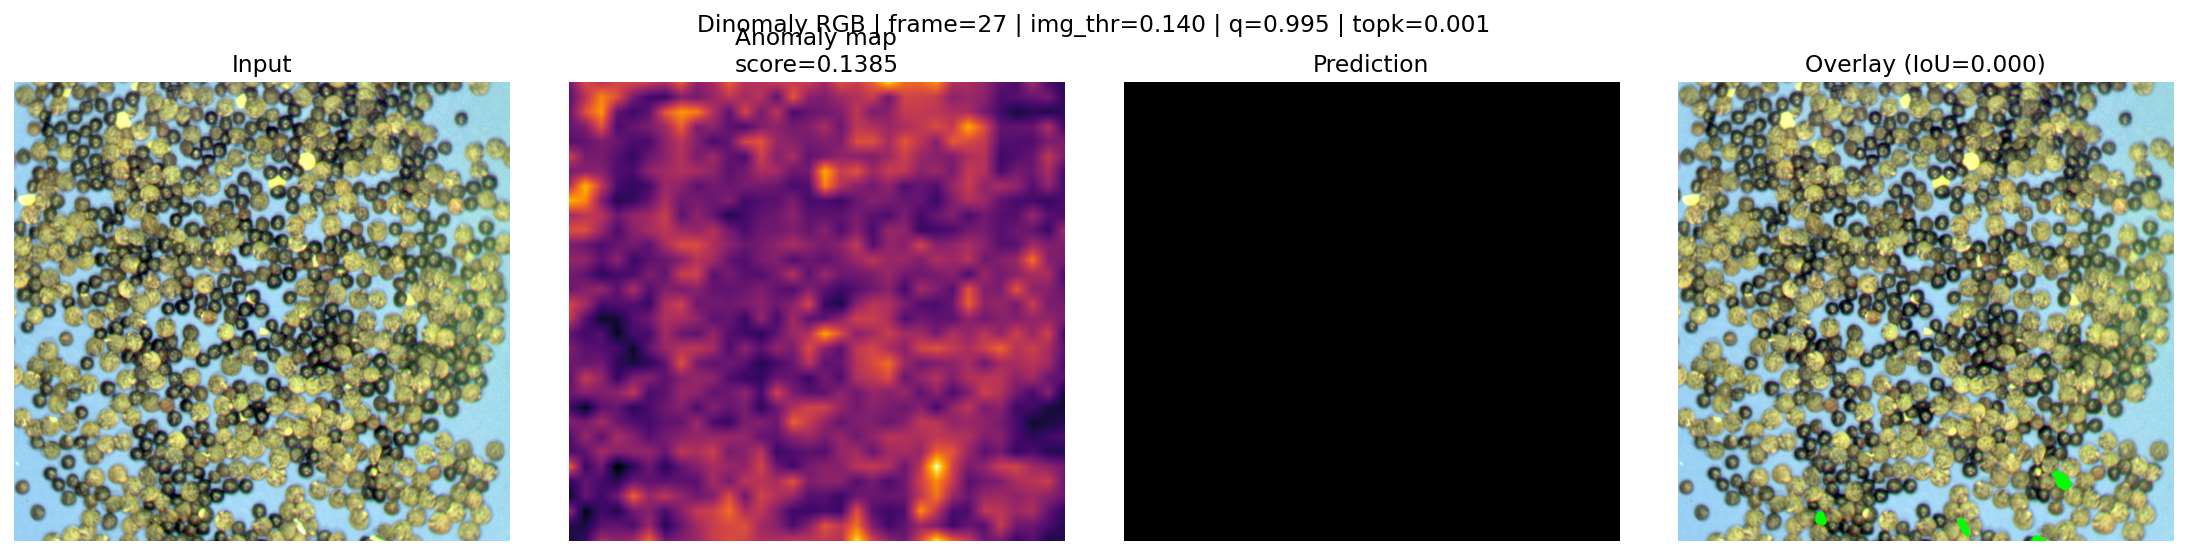

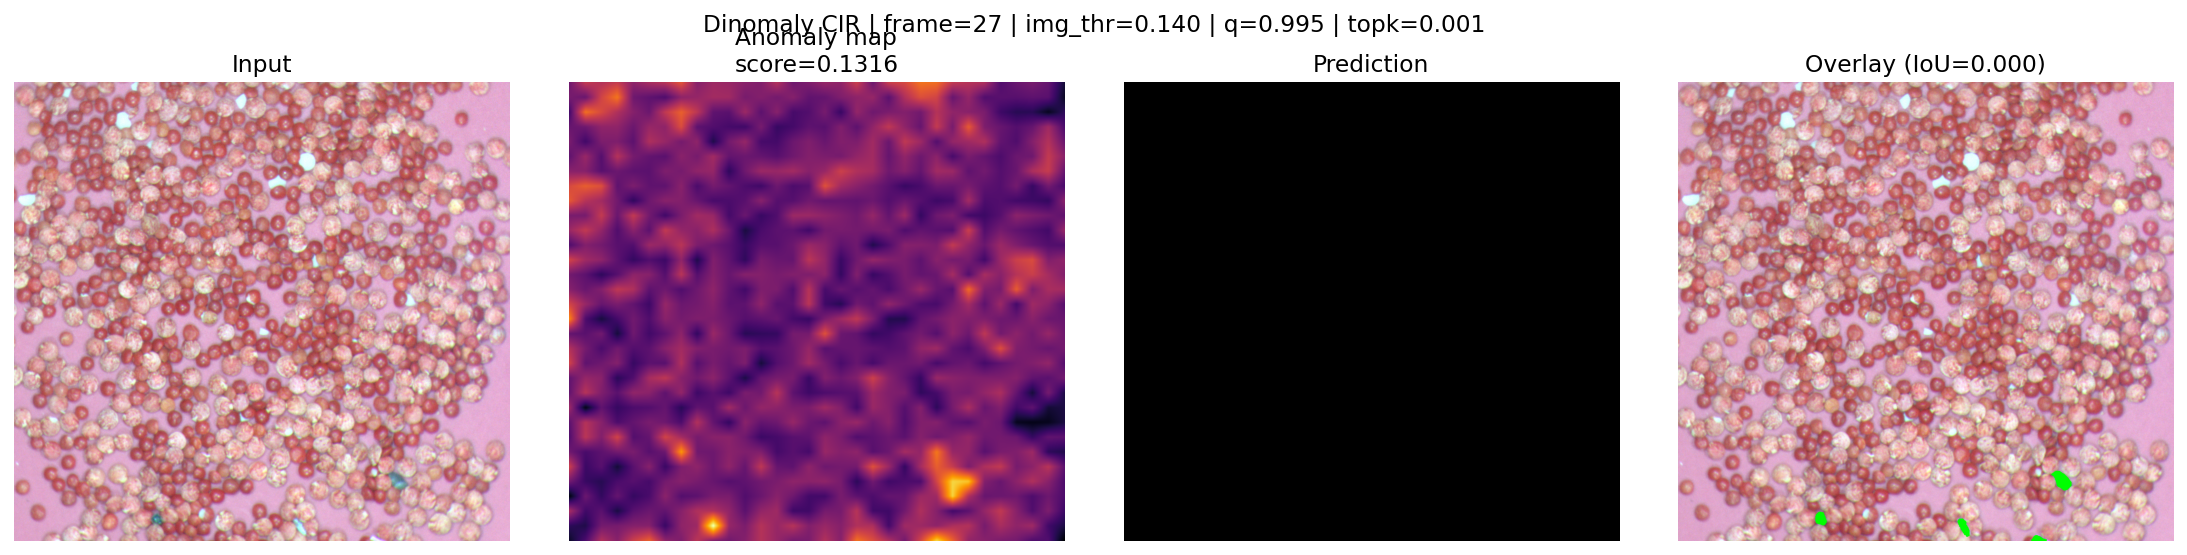

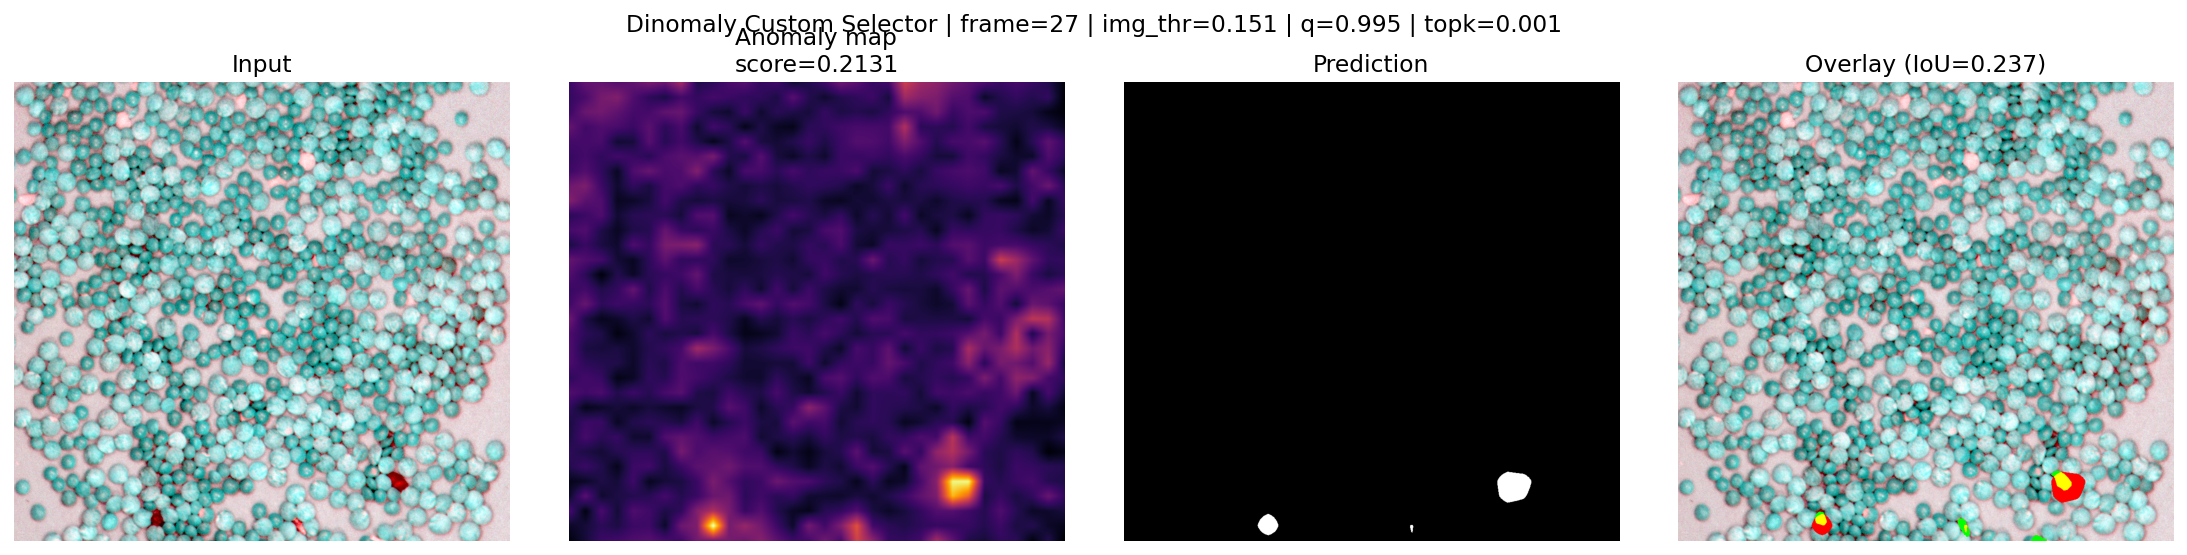

In [9]:
for method in config['methods']:
    row = next(
        (r for r in preview_results[method.name] if int(r['frame_idx']) == PREVIEW_FRAME_ID),
        preview_results[method.name][0],
    )
    render_method_triplet(
        row,
        title=(
            f"{method.title} | frame={row['frame_idx']} | "
            f"img_thr={method.image_threshold:.3f} | q={method.quantile:.3f} | "
            f"topk={method.top_k_fraction:g}"
        ),
    )
    plt.show()

## 7 · Export overlay videos for all frames

Now we render all frames at **4 FPS** for visual comparison. The notebook uses the generated
videos if they already exist; otherwise it can regenerate them from the live pipelines.

Primary writer: `ToVideoNode`.
Fallback writer: OpenCV AVI writer if MP4 fails.

This section does not write NPZ dumps.

In [ ]:
VIDEO_FPS = 4.0
RUN_VIDEO_EXPORT_IF_MISSING = True

expected_video_paths = {
    m.name: output_dir / f'{m.name}_overlay_4fps.mp4'
    for m in config['methods']
}

missing = [name for name, path in expected_video_paths.items() if not path.exists()]
print('Existing videos:')
for name, path in expected_video_paths.items():
    print(f'- {METHOD_TITLES[name]}: {path} | exists={path.exists()}')

if missing and RUN_VIDEO_EXPORT_IF_MISSING:
    print('\nMissing videos will be generated:', missing)
    all_frame_indices = set(range(len(dm.predict_ds)))
    full_results = {}
    for method in config['methods']:
        print(f'Full inference for {method.title} ...')
        pipe = load_pipeline_for_inference(
            yaml_path=method.yaml_path,
            pt_path=method.pt_path,
            plugins_manifest=config['plugins_manifest'],
            device=str(device),
        )
        full_results[method.name] = run_method_on_frame_subset(
            pipeline=pipe,
            loader=loader,
            frame_indices=all_frame_indices,
            image_threshold=method.image_threshold,
            quantile=method.quantile,
            top_k_fraction=method.top_k_fraction,
            device=device,
            normal_class_ids=NORMAL_CLASS_IDS,
        )

    for method in config['methods']:
        path = export_overlay_video(
            rows=full_results[method.name],
            output_path=expected_video_paths[method.name],
            fps=VIDEO_FPS,
            overlay_title=f'{method.title} | thr={method.image_threshold:.3f} q={method.quantile:.3f} topk={method.top_k_fraction:g}',
        )
        expected_video_paths[method.name] = path
elif missing:
    print('\nSome videos are missing. Set RUN_VIDEO_EXPORT_IF_MISSING=True to generate them.')

Existing videos:
- Dinomaly RGB: /home/dev/anish/cuvis-ai-dinomaly/notebooks/lentils_sliding/outputs/Auto_003+01/dinomaly_rgb_overlay_4fps.mp4 | exists=True
- Dinomaly CIR: /home/dev/anish/cuvis-ai-dinomaly/notebooks/lentils_sliding/outputs/Auto_003+01/dinomaly_cir_overlay_4fps.mp4 | exists=True
- Dinomaly Custom Selector: /home/dev/anish/cuvis-ai-dinomaly/notebooks/lentils_sliding/outputs/Auto_003+01/dinomaly_concrete_overlay_4fps.mp4 | exists=True


## 8 · Watch the three method videos

These videos make the comparison easiest to understand in a meeting or tutorial:

- RGB: baseline visible view.
- CIR: near-infrared material contrast.
- Custom selector: task-selected bands from the prior selector experiment.

If inline display fails in a remote browser, use the printed file paths and open/download the MP4 files.

In [ ]:
for method in config['methods']:
    path = expected_video_paths[method.name]
    print(f'\n{method.title}: {path}')
    if path.exists():
        display(Video(filename=str(path), embed=IN_COLAB, width=720, html_attributes='controls loop'))
    else:
        print('Missing video file.')


Dinomaly RGB: /home/dev/anish/cuvis-ai-dinomaly/notebooks/lentils_sliding/outputs/Auto_003+01/dinomaly_rgb_overlay_4fps.mp4



Dinomaly CIR: /home/dev/anish/cuvis-ai-dinomaly/notebooks/lentils_sliding/outputs/Auto_003+01/dinomaly_cir_overlay_4fps.mp4



Dinomaly Custom Selector: /home/dev/anish/cuvis-ai-dinomaly/notebooks/lentils_sliding/outputs/Auto_003+01/dinomaly_concrete_overlay_4fps.mp4


## 9 · Takeaways

For this lentils use case, the main lesson is that **channel choice matters**.
The detector architecture can stay fixed, while the hyperspectral-to-3-channel projection changes
what material contrasts are visible to the model.

